# 🐄 Cattle Breed Classifier — Vision Transformer (ViT-Base/16)
### Best Model from Comparison Study | 96.52% Validation Accuracy
### Full Pipeline: Data EDA → Training (with Augmentation) → Testing → Evaluation

---
**Model:** `vit_base_patch16_224` (pretrained on ImageNet-21k via `timm`)  
**Training Strategy:** 2-Phase Fine-tuning (head → last 4 transformer blocks)  
**Outputs:** Training curves, sample image grid, confusion matrix, per-class report

In [1]:
# ═══════════════════════════════════════════════════════════════
# CELL 1 — Install Dependencies
# ═══════════════════════════════════════════════════════════════
!pip install timm -q
print("✅ timm installed")

✅ timm installed


In [2]:
# ═══════════════════════════════════════════════════════════════
# CELL 2 — Imports & Global Config
# ═══════════════════════════════════════════════════════════════
import os, random, json, warnings
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import seaborn as sns
from PIL import Image
from collections import Counter

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
import timm

from sklearn.metrics import (
    confusion_matrix, classification_report,
    accuracy_score, f1_score
)

warnings.filterwarnings('ignore')

# ── Reproducibility ──
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True

# ── Config ──
DATA_DIR   = '/content/drive/MyDrive/capstone/cattle dataset'
IMG_SIZE   = (224, 224)
BATCH_SIZE = 16
NUM_EPOCHS = 40      # max; early stopping will kick in
VAL_SPLIT  = 0.2
DEVICE     = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f'timm  : {timm.__version__}')
print(f'torch : {torch.__version__}')
print(f'device: {DEVICE}')
print(f'CUDA  : {torch.cuda.get_device_name(0) if torch.cuda.is_available() else "N/A"}')

timm  : 1.0.26
torch : 2.10.0+cu128
device: cuda
CUDA  : Tesla T4


In [3]:
# ═══════════════════════════════════════════════════════════════
# CELL 3 — Mount Google Drive
# ═══════════════════════════════════════════════════════════════
from google.colab import drive
drive.mount('/content/drive')
print('Drive mounted.')

Mounted at /content/drive
Drive mounted.


---
## 📊 Section 1 — Exploratory Data Analysis (EDA)

Dataset: /content/drive/MyDrive/capstone/cattle dataset
Total Classes : 5
Total Images  : 1004
Train Split   : ~803 (80%)
Val Split     : ~201  (20%)
Class Breakdown:
  Gir                    210 images  (20.9%)
  Holstein Friesian      337 images  (33.6%)
  Jersey                 172 images  (17.1%)
  Tharparkar             187 images  (18.6%)
  sahiwal                 98 images  (9.8%)


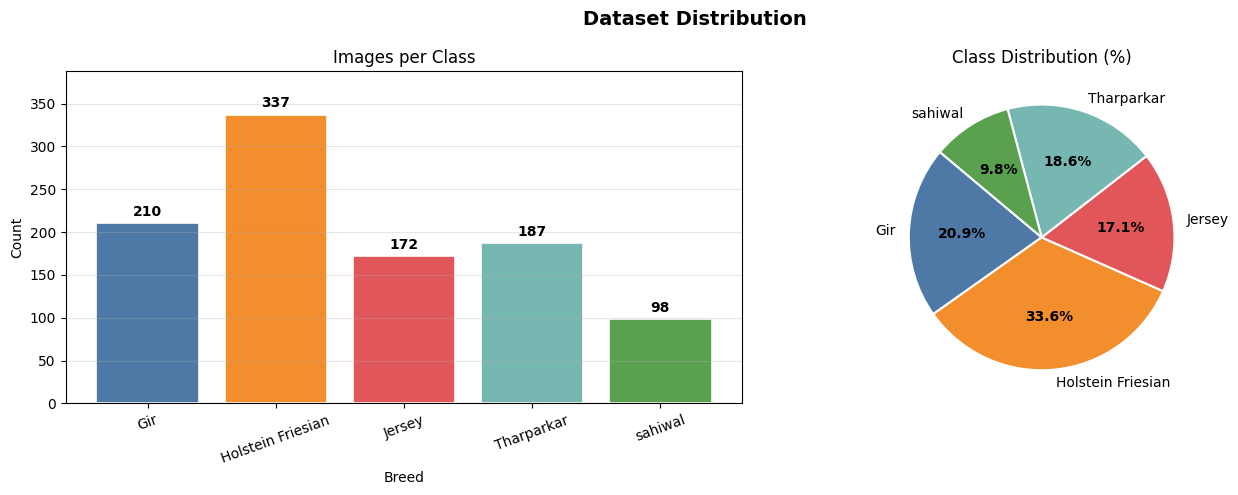

Figure saved: eda_distribution.png


In [ ]:
# ═══════════════════════════════════════════════════════════════
# CELL 4 — Dataset Overview & Distribution
# ═══════════════════════════════════════════════════════════════
class_names  = sorted(os.listdir(DATA_DIR))
NUM_CLASSES  = len(class_names)
class_to_idx = {cls: i for i, cls in enumerate(class_names)}

# Count images per class
class_counts = {}
for cls in class_names:
    cls_dir = os.path.join(DATA_DIR, cls)
    imgs = [f for f in os.listdir(cls_dir)
            if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    class_counts[cls] = len(imgs)

total_images = sum(class_counts.values())
train_count  = int(total_images * (1 - VAL_SPLIT))
val_count    = total_images - train_count

print('=' * 55)
print(f'Dataset: {DATA_DIR}')
print(f'Total Classes : {NUM_CLASSES}')
print(f'Total Images  : {total_images}')
print(f'Train Split   : ~{train_count} ({(1-VAL_SPLIT)*100:.0f}%)')
print(f'Val Split     : ~{val_count}  ({VAL_SPLIT*100:.0f}%)')
print('=' * 55)
print('Class Breakdown:')
for cls, cnt in class_counts.items():
    pct = cnt / total_images * 100
    print(f'  {cls:<20} {cnt:>5} images  ({pct:.1f}%)')

# ── PALETTE ──
PALETTE = ['#4e79a7', '#f28e2b', '#e15759', '#76b7b2', '#59a14f',
           '#edc948', '#b07aa1', '#ff9da7', '#9c755f', '#bab0ac']
colors = PALETTE[:NUM_CLASSES]

# ── Figure 1: Distribution Bar Chart ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Dataset Distribution', fontsize=14, fontweight='bold')

# Bar chart
bars = axes[0].bar(class_counts.keys(), class_counts.values(),
                   color=colors, edgecolor='white', linewidth=1.2)
for bar, val in zip(bars, class_counts.values()):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + total_images * 0.005,
                 str(val), ha='center', va='bottom', fontweight='bold', fontsize=10)
axes[0].set_title('Images per Class', fontsize=12)
axes[0].set_xlabel('Breed')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=20)
axes[0].grid(axis='y', alpha=0.3)
axes[0].set_ylim([0, max(class_counts.values()) * 1.15])

# Pie chart
wedges, texts, autotexts = axes[1].pie(
    class_counts.values(),
    labels=class_counts.keys(),
    colors=colors,
    autopct='%1.1f%%',
    startangle=140,
    wedgeprops=dict(edgecolor='white', linewidth=1.5)
)
for at in autotexts:
    at.set_fontweight('bold')
axes[1].set_title('Class Distribution (%)', fontsize=12)

plt.tight_layout()
plt.savefig('eda_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: eda_distribution.png')

In [ ]:
# ═══════════════════════════════════════════════════════════════
# CELL 5 — Sample Images Grid (one column per breed)
# ═══════════════════════════════════════════════════════════════
N_ROWS = 4   # rows per breed

fig, axes = plt.subplots(N_ROWS, NUM_CLASSES,
                          figsize=(NUM_CLASSES * 3, N_ROWS * 3))

for col, (cls, color) in enumerate(zip(class_names, colors)):
    cls_dir = os.path.join(DATA_DIR, cls)
    all_imgs = [f for f in os.listdir(cls_dir)
                if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    samples = random.sample(all_imgs, min(N_ROWS, len(all_imgs)))

    for row in range(N_ROWS):
        ax = axes[row, col] if NUM_CLASSES > 1 else axes[row]
        if row < len(samples):
            img_path = os.path.join(cls_dir, samples[row])
            img = Image.open(img_path).convert('RGB')
            ax.imshow(img)
        else:
            ax.axis('off')
            continue

        ax.set_xticks([])
        ax.set_yticks([])

        if row == 0:
            ax.set_title(cls, fontsize=11, fontweight='bold', color='white',
                         bbox=dict(boxstyle='round,pad=0.3',
                                   facecolor=color, edgecolor='none'))
        for spine in ax.spines.values():
            spine.set_edgecolor(color)
            spine.set_linewidth(2.5)

fig.suptitle('📷 Sample Images — Each Column = One Breed',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('eda_sample_images.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: eda_sample_images.png')

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
# ═══════════════════════════════════════════════════════════════
# CELL 6 — Augmentation Preview
# ═══════════════════════════════════════════════════════════════
aug_preview_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=1.0),
    transforms.RandomRotation(30),
    transforms.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.3),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), shear=15),
])

# Pick one random image per breed
N_AUG_COLS = 5   # number of augmented variants shown
fig, axes = plt.subplots(NUM_CLASSES, N_AUG_COLS + 1,
                          figsize=((N_AUG_COLS + 1) * 2.5, NUM_CLASSES * 2.5))

for row, (cls, color) in enumerate(zip(class_names, colors)):
    cls_dir = os.path.join(DATA_DIR, cls)
    img_files = [f for f in os.listdir(cls_dir)
                 if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    img_path = os.path.join(cls_dir, random.choice(img_files))
    orig_img = Image.open(img_path).convert('RGB').resize((224, 224))

    # Column 0 = original
    ax = axes[row, 0]
    ax.imshow(orig_img)
    ax.set_xticks([]); ax.set_yticks([])
    if row == 0:
        ax.set_title('Original', fontsize=10, fontweight='bold')
    ax.set_ylabel(cls, fontsize=9, fontweight='bold', color=color,
                  rotation=0, labelpad=60, va='center')
    for spine in ax.spines.values():
        spine.set_edgecolor(color); spine.set_linewidth(2)

    # Columns 1..N_AUG_COLS = augmented variants
    for col in range(1, N_AUG_COLS + 1):
        aug_img = aug_preview_transform(orig_img)
        ax = axes[row, col]
        ax.imshow(aug_img)
        ax.set_xticks([]); ax.set_yticks([])
        if row == 0:
            ax.set_title(f'Aug #{col}', fontsize=10)
        for spine in ax.spines.values():
            spine.set_edgecolor(color); spine.set_linewidth(1.5)

fig.suptitle('Data Augmentation Preview (Original + 5 Variants per Breed)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_augmentation_preview.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: eda_augmentation_preview.png')

Output hidden; open in https://colab.research.google.com to view.

---
## 🏗️ Section 2 — Dataset & DataLoader Setup

In [ ]:
# ═══════════════════════════════════════════════════════════════
# CELL 7 — Dataset Class & Transforms
# ═══════════════════════════════════════════════════════════════
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

class CattleDataset(Dataset):
    """
    Custom dataset for cattle breed images.
    Supports train/val split with fixed seed for reproducibility.
    """
    def __init__(self, data_dir, class_to_idx, transform=None,
                 split='train', val_split=0.2, seed=42):
        all_samples = []
        for cls, idx in class_to_idx.items():
            cls_dir = os.path.join(data_dir, cls)
            for fname in os.listdir(cls_dir):
                if fname.lower().endswith(('.jpg', '.jpeg', '.png')):
                    all_samples.append((os.path.join(cls_dir, fname), idx))

        random.seed(seed)
        random.shuffle(all_samples)
        split_point = int(len(all_samples) * (1 - val_split))

        self.samples   = all_samples[:split_point] if split == 'train' else all_samples[split_point:]
        self.transform = transform
        self.classes   = [s[1] for s in self.samples]

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, label

# ── Transforms ──
train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.1),
    transforms.RandomRotation(30),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, hue=0.05),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), shear=10),
    transforms.RandomGrayscale(p=0.05),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    transforms.RandomErasing(p=0.2, scale=(0.02, 0.15))
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])

# ── Build datasets ──
train_dataset = CattleDataset(DATA_DIR, class_to_idx, train_transform,
                               split='train', val_split=VAL_SPLIT)
val_dataset   = CattleDataset(DATA_DIR, class_to_idx, val_transform,
                               split='val',   val_split=VAL_SPLIT)

# ── Build loaders ──
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=2, pin_memory=True)

print(f'Train samples : {len(train_dataset)}')
print(f'Val samples   : {len(val_dataset)}')
print(f'Train batches : {len(train_loader)}')
print(f'Val batches   : {len(val_loader)}')
print(f'Classes       : {class_names}')

Train samples : 803
Val samples   : 201
Train batches : 51
Val batches   : 13
Classes       : ['Gir', 'Holstein Friesian', 'Jersey', 'Tharparkar', 'sahiwal']


---
## 🤖 Section 3 — ViT Model Definition

In [ ]:
# ═══════════════════════════════════════════════════════════════
# CELL 8 — Build ViT Model
# ═══════════════════════════════════════════════════════════════
def build_vit(num_classes, pretrained=True):
    """
    Loads pretrained ViT-Base/16 (ImageNet-21k) from timm.
    All weights frozen initially — only classification head trainable.
    """
    model = timm.create_model(
        'vit_base_patch16_224',
        pretrained=pretrained,
        num_classes=num_classes
    )
    # Freeze all parameters
    for param in model.parameters():
        param.requires_grad = False
    # Unfreeze classification head only
    for param in model.head.parameters():
        param.requires_grad = True
    return model

vit_model = build_vit(NUM_CLASSES)
vit_model = vit_model.to(DEVICE)

# ── Parameter counts ──
total_params    = sum(p.numel() for p in vit_model.parameters())
trainable_params = sum(p.numel() for p in vit_model.parameters() if p.requires_grad)
frozen_params   = total_params - trainable_params

print('=' * 50)
print('ViT-Base/16 — Model Summary')
print('=' * 50)
print(f'Total parameters    : {total_params:,}')
print(f'Trainable (Phase 1) : {trainable_params:,}  ({trainable_params/total_params*100:.2f}%)')
print(f'Frozen              : {frozen_params:,}')
print(f'Input size          : 224 × 224 × 3')
print(f'Patch size          : 16 × 16')
print(f'Num patches         : {(224//16)**2} + 1 CLS token = {(224//16)**2 + 1}')
print(f'Transformer blocks  : {len(vit_model.blocks)}')
print(f'Hidden dim          : 768')
print(f'Attention heads     : 12')
print(f'Output classes      : {NUM_CLASSES}')
print('=' * 50)

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

ViT-Base/16 — Model Summary
Total parameters    : 85,802,501
Trainable (Phase 1) : 3,845  (0.00%)
Frozen              : 85,798,656
Input size          : 224 × 224 × 3
Patch size          : 16 × 16
Num patches         : 196 + 1 CLS token = 197
Transformer blocks  : 12
Hidden dim          : 768
Attention heads     : 12
Output classes      : 5


---
## 🚀 Section 4 — Training

In [ ]:
# ═══════════════════════════════════════════════════════════════
# CELL 9 — Training Engine
# ═══════════════════════════════════════════════════════════════
def run_epoch(model, loader, criterion, optimizer=None, phase='train'):
    """
    Runs one epoch. If optimizer is None → eval mode (no gradient).
    Returns: (avg_loss, accuracy)
    """
    is_train = (phase == 'train' and optimizer is not None)
    model.train() if is_train else model.eval()

    total_loss, correct, total = 0.0, 0, 0
    context = torch.enable_grad() if is_train else torch.no_grad()

    with context:
        for imgs, labels in loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)

            if is_train:
                optimizer.zero_grad()

            outputs = model(imgs)
            loss    = criterion(outputs, labels)

            if is_train:
                loss.backward()
                optimizer.step()

            total_loss += loss.item()
            preds      = outputs.argmax(dim=1)
            correct    += (preds == labels).sum().item()
            total      += labels.size(0)

    return total_loss / len(loader), correct / total


def train_phase(model, train_loader, val_loader, epochs, lr, tag,
                patience=10, history=None):
    """
    Trains model for `epochs` with AdamW + CosineAnnealingLR.
    Saves best checkpoint. Returns updated history dict.
    """
    if history is None:
        history = {'train_acc': [], 'val_acc': [],
                   'train_loss': [], 'val_loss': []}

    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    optimizer = optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=lr, weight_decay=1e-4
    )
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-7)

    best_val_acc = 0.0
    wait         = 0

    for epoch in range(1, epochs + 1):
        tr_loss, tr_acc = run_epoch(model, train_loader, criterion, optimizer, 'train')
        vl_loss, vl_acc = run_epoch(model, val_loader,   criterion, None,      'val')
        scheduler.step()

        history['train_acc'].append(tr_acc)
        history['val_acc'].append(vl_acc)
        history['train_loss'].append(tr_loss)
        history['val_loss'].append(vl_loss)

        current_lr = scheduler.get_last_lr()[0]
        print(f'  [{tag}] Epoch {epoch:>3}/{epochs} | '
              f'train_acc: {tr_acc:.4f} | val_acc: {vl_acc:.4f} | '
              f'lr: {current_lr:.2e}')

        if vl_acc > best_val_acc:
            best_val_acc = vl_acc
            wait = 0
            torch.save(model.state_dict(), f'best_vit_{tag}.pth')
            print(f'  ✅ New best val_acc: {best_val_acc:.4f} — checkpoint saved.')
        else:
            wait += 1
            if wait >= patience:
                print(f'  ⏹  Early stopping after {patience} epochs without improvement.')
                break

    # Restore best weights
    model.load_state_dict(torch.load(f'best_vit_{tag}.pth'))
    print(f'\n  Phase [{tag}] complete. Best val_acc = {best_val_acc*100:.2f}%')
    return history, best_val_acc

print('Training engine ready.')

Training engine ready.


In [ ]:
# ═══════════════════════════════════════════════════════════════
# CELL 10 — Phase 1: Train Classification Head Only
# ═══════════════════════════════════════════════════════════════
print('=' * 60)
print('PHASE 1 — Training Classification Head (Backbone Frozen)')
print('=' * 60)

trainable_p1 = sum(p.numel() for p in vit_model.parameters() if p.requires_grad)
print(f'Trainable params (Phase 1): {trainable_p1:,}\n')

history, best_p1 = train_phase(
    vit_model, train_loader, val_loader,
    epochs=15, lr=1e-3, tag='phase1', patience=8
)

print(f'\n✅ Phase 1 best val_acc: {best_p1*100:.2f}%')

PHASE 1 — Training Classification Head (Backbone Frozen)
Trainable params (Phase 1): 3,845

  [phase1] Epoch   1/15 | train_acc: 0.6638 | val_acc: 0.8060 | lr: 9.89e-04
  ✅ New best val_acc: 0.8060 — checkpoint saved.
  [phase1] Epoch   2/15 | train_acc: 0.8717 | val_acc: 0.9055 | lr: 9.57e-04
  ✅ New best val_acc: 0.9055 — checkpoint saved.
  [phase1] Epoch   3/15 | train_acc: 0.9041 | val_acc: 0.9005 | lr: 9.05e-04
  [phase1] Epoch   4/15 | train_acc: 0.9116 | val_acc: 0.9254 | lr: 8.35e-04
  ✅ New best val_acc: 0.9254 — checkpoint saved.
  [phase1] Epoch   5/15 | train_acc: 0.9240 | val_acc: 0.9303 | lr: 7.50e-04
  ✅ New best val_acc: 0.9303 — checkpoint saved.
  [phase1] Epoch   6/15 | train_acc: 0.9153 | val_acc: 0.9453 | lr: 6.55e-04
  ✅ New best val_acc: 0.9453 — checkpoint saved.
  [phase1] Epoch   7/15 | train_acc: 0.9290 | val_acc: 0.9403 | lr: 5.52e-04
  [phase1] Epoch   8/15 | train_acc: 0.9215 | val_acc: 0.9403 | lr: 4.48e-04
  [phase1] Epoch   9/15 | train_acc: 0.9440 | v

In [ ]:
# ═══════════════════════════════════════════════════════════════
# CELL 11 — Phase 2: Fine-tune Last 4 Transformer Blocks
# ═══════════════════════════════════════════════════════════════
print('=' * 60)
print('PHASE 2 — Fine-tuning Last 4 Transformer Blocks')
print('=' * 60)

# Unfreeze: last 4 blocks + norm layer + head
for param in vit_model.parameters():
    param.requires_grad = False

total_blocks = len(vit_model.blocks)
for i in range(total_blocks - 4, total_blocks):
    for param in vit_model.blocks[i].parameters():
        param.requires_grad = True

for param in vit_model.norm.parameters():
    param.requires_grad = True
for param in vit_model.head.parameters():
    param.requires_grad = True

trainable_p2 = sum(p.numel() for p in vit_model.parameters() if p.requires_grad)
print(f'Unfrozen blocks     : {total_blocks-4} to {total_blocks-1} (last 4)')
print(f'Trainable params    : {trainable_p2:,}\n')

history, best_p2 = train_phase(
    vit_model, train_loader, val_loader,
    epochs=30, lr=5e-5, tag='phase2', patience=10,
    history=history
)

print(f'\n✅ Phase 2 best val_acc: {best_p2*100:.2f}%')
BEST_VAL_ACC = max(best_p1, best_p2)

PHASE 2 — Fine-tuning Last 4 Transformer Blocks
Unfrozen blocks     : 8 to 11 (last 4)
Trainable params    : 28,356,869

  [phase2] Epoch   1/30 | train_acc: 0.8979 | val_acc: 0.9154 | lr: 4.99e-05
  ✅ New best val_acc: 0.9154 — checkpoint saved.
  [phase2] Epoch   2/30 | train_acc: 0.9514 | val_acc: 0.9403 | lr: 4.95e-05
  ✅ New best val_acc: 0.9403 — checkpoint saved.
  [phase2] Epoch   3/30 | train_acc: 0.9514 | val_acc: 0.9254 | lr: 4.88e-05
  [phase2] Epoch   4/30 | train_acc: 0.9502 | val_acc: 0.9502 | lr: 4.78e-05
  ✅ New best val_acc: 0.9502 — checkpoint saved.
  [phase2] Epoch   5/30 | train_acc: 0.9714 | val_acc: 0.9602 | lr: 4.67e-05
  ✅ New best val_acc: 0.9602 — checkpoint saved.
  [phase2] Epoch   6/30 | train_acc: 0.9676 | val_acc: 0.9353 | lr: 4.52e-05
  [phase2] Epoch   7/30 | train_acc: 0.9863 | val_acc: 0.9552 | lr: 4.36e-05
  [phase2] Epoch   8/30 | train_acc: 0.9875 | val_acc: 0.9403 | lr: 4.17e-05
  [phase2] Epoch   9/30 | train_acc: 0.9913 | val_acc: 0.9602 | lr:

---
## 📈 Section 5 — Training Curves

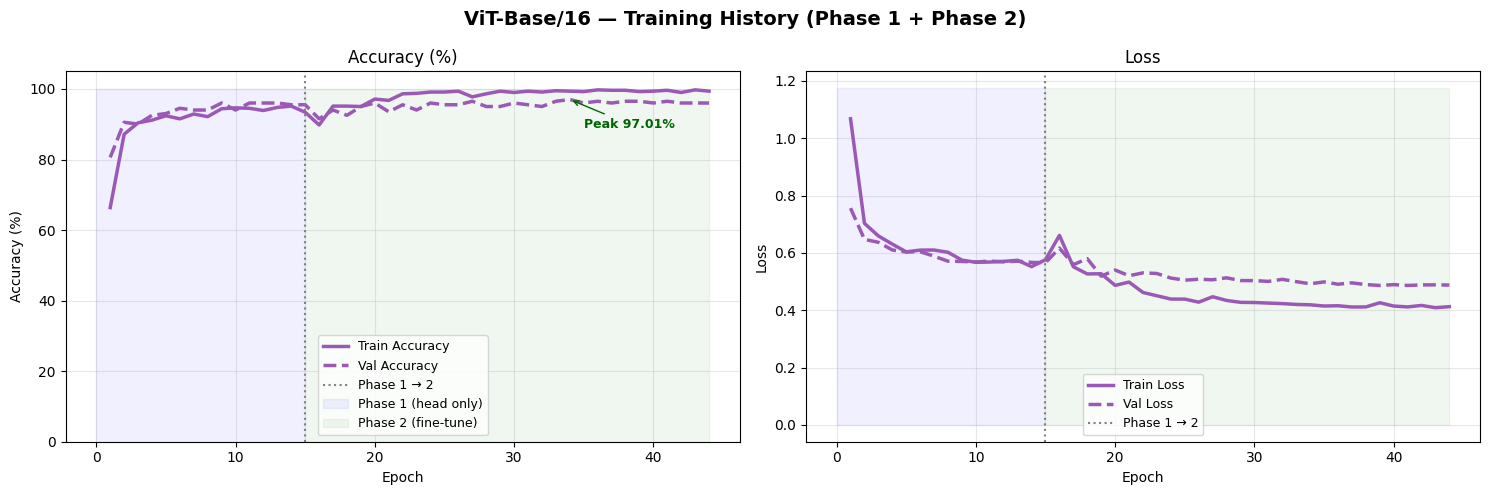

Figure saved: vit_training_history.png


In [ ]:
# ═══════════════════════════════════════════════════════════════
# CELL 12 — Training History Plots
# ═══════════════════════════════════════════════════════════════
epochs_ran  = list(range(1, len(history['train_acc']) + 1))
phase1_end  = min(15, len(history['train_acc']))  # where phase 2 started

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('ViT-Base/16 — Training History (Phase 1 + Phase 2)',
             fontsize=14, fontweight='bold')

VIT_COLOR = '#9b59b6'

# ── Accuracy ──
axes[0].plot(epochs_ran, [a*100 for a in history['train_acc']],
             label='Train Accuracy', color=VIT_COLOR, linewidth=2.5)
axes[0].plot(epochs_ran, [a*100 for a in history['val_acc']],
             label='Val Accuracy',   color=VIT_COLOR, linewidth=2.5,
             linestyle='--')
axes[0].axvline(x=phase1_end, color='gray', linestyle=':', linewidth=1.5,
                label='Phase 1 → 2')
axes[0].fill_betweenx([0, 100], 0, phase1_end, alpha=0.06, color='blue',
                       label='Phase 1 (head only)')
axes[0].fill_betweenx([0, 100], phase1_end, max(epochs_ran), alpha=0.06,
                       color='green', label='Phase 2 (fine-tune)')
best_val = max(history['val_acc']) * 100
best_ep  = history['val_acc'].index(max(history['val_acc'])) + 1
axes[0].annotate(f'Peak {best_val:.2f}%',
                 xy=(best_ep, best_val),
                 xytext=(best_ep + 1, best_val - 8),
                 fontsize=9, fontweight='bold', color='darkgreen',
                 arrowprops=dict(arrowstyle='->', color='darkgreen'))
axes[0].set_title('Accuracy (%)', fontsize=12)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy (%)')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim([0, 105])

# ── Loss ──
axes[1].plot(epochs_ran, history['train_loss'],
             label='Train Loss', color=VIT_COLOR, linewidth=2.5)
axes[1].plot(epochs_ran, history['val_loss'],
             label='Val Loss',   color=VIT_COLOR, linewidth=2.5, linestyle='--')
axes[1].axvline(x=phase1_end, color='gray', linestyle=':', linewidth=1.5,
                label='Phase 1 → 2')
axes[1].fill_betweenx([0, max(history['train_loss'])*1.1], 0, phase1_end,
                       alpha=0.06, color='blue')
axes[1].fill_betweenx([0, max(history['train_loss'])*1.1], phase1_end,
                       max(epochs_ran), alpha=0.06, color='green')
axes[1].set_title('Loss', fontsize=12)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('vit_training_history.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: vit_training_history.png')

---
## 🧪 Section 6 — Evaluation on Validation Set (Testing)

In [ ]:
# ═══════════════════════════════════════════════════════════════
# CELL 13 — Inference on Validation Set
# ═══════════════════════════════════════════════════════════════
def get_all_predictions(model, loader, device):
    """Returns (all_preds, all_labels, all_probs) arrays."""
    model.eval()
    all_preds, all_labels, all_probs = [], [], []

    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(device)
            outputs = model(imgs)
            probs   = torch.softmax(outputs, dim=1).cpu().numpy()
            preds   = outputs.argmax(dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.numpy())
            all_probs.extend(probs)

    return (np.array(all_preds),
            np.array(all_labels),
            np.array(all_probs))

print('Running inference on validation set...')
y_pred, y_true, y_probs = get_all_predictions(vit_model, val_loader, DEVICE)

val_acc   = accuracy_score(y_true, y_pred)
val_f1    = f1_score(y_true, y_pred, average='weighted')
macro_f1  = f1_score(y_true, y_pred, average='macro')

print('\n' + '=' * 55)
print('📊 VALIDATION SET RESULTS')
print('=' * 55)
print(f'Validation Accuracy  : {val_acc*100:.2f}%')
print(f'Weighted F1-Score    : {val_f1:.4f}')
print(f'Macro F1-Score       : {macro_f1:.4f}')
print('=' * 55)
print('\nPer-class Classification Report:')
print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

Running inference on validation set...

📊 VALIDATION SET RESULTS
Validation Accuracy  : 97.01%
Weighted F1-Score    : 0.9699
Macro F1-Score       : 0.9616

Per-class Classification Report:
                   precision    recall  f1-score   support

              Gir     0.9744    0.9500    0.9620        40
Holstein Friesian     0.9677    1.0000    0.9836        60
           Jersey     0.9737    0.9737    0.9737        38
       Tharparkar     1.0000    1.0000    1.0000        40
          sahiwal     0.9091    0.8696    0.8889        23

         accuracy                         0.9701       201
        macro avg     0.9650    0.9586    0.9616       201
     weighted avg     0.9699    0.9701    0.9699       201



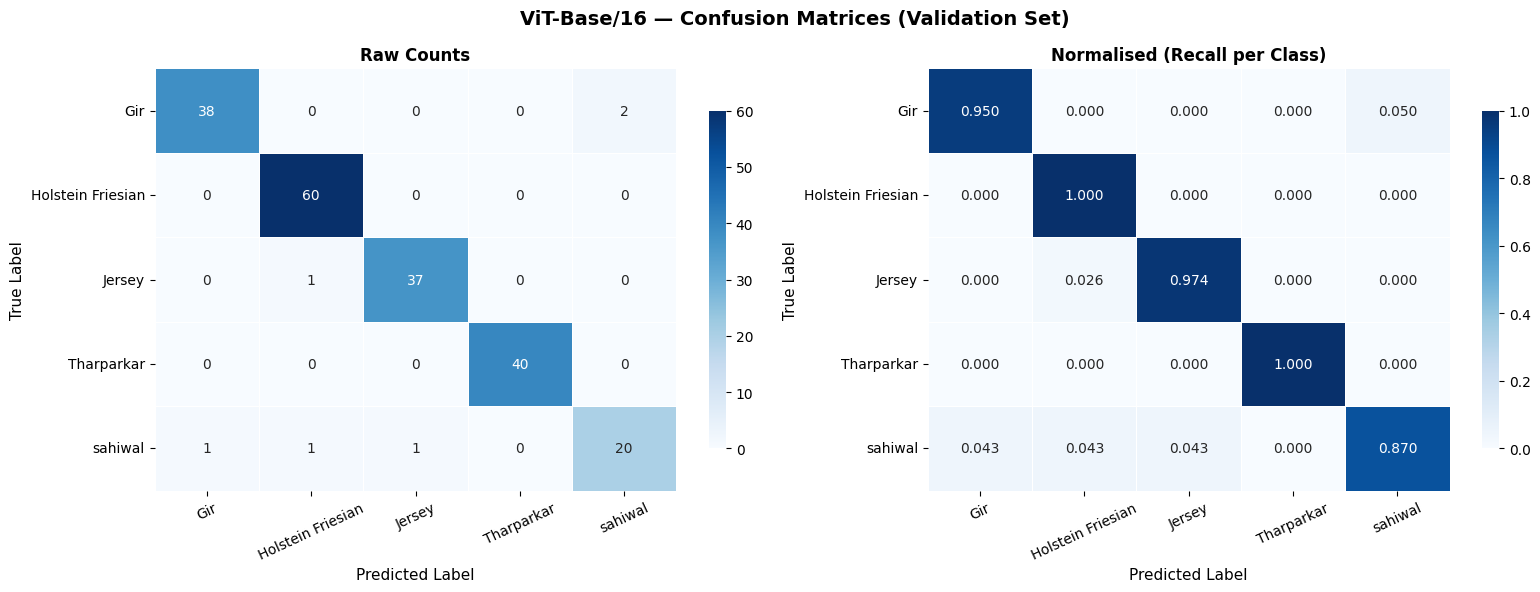

Figure saved: vit_confusion_matrix_val.png


In [ ]:
# ═══════════════════════════════════════════════════════════════
# CELL 14 — Confusion Matrix (Validation)
# ═══════════════════════════════════════════════════════════════
cm      = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('ViT-Base/16 — Confusion Matrices (Validation Set)',
             fontsize=14, fontweight='bold')

# Raw counts
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            linewidths=0.5, ax=axes[0], cbar_kws={'shrink': 0.8})
axes[0].set_title('Raw Counts', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Predicted Label', fontsize=11)
axes[0].set_ylabel('True Label', fontsize=11)
axes[0].tick_params(axis='x', rotation=25)
axes[0].tick_params(axis='y', rotation=0)

# Normalised
sns.heatmap(cm_norm, annot=True, fmt='.3f', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            linewidths=0.5, ax=axes[1], cbar_kws={'shrink': 0.8},
            vmin=0, vmax=1)
axes[1].set_title('Normalised (Recall per Class)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Predicted Label', fontsize=11)
axes[1].set_ylabel('True Label', fontsize=11)
axes[1].tick_params(axis='x', rotation=25)
axes[1].tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.savefig('vit_confusion_matrix_val.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: vit_confusion_matrix_val.png')

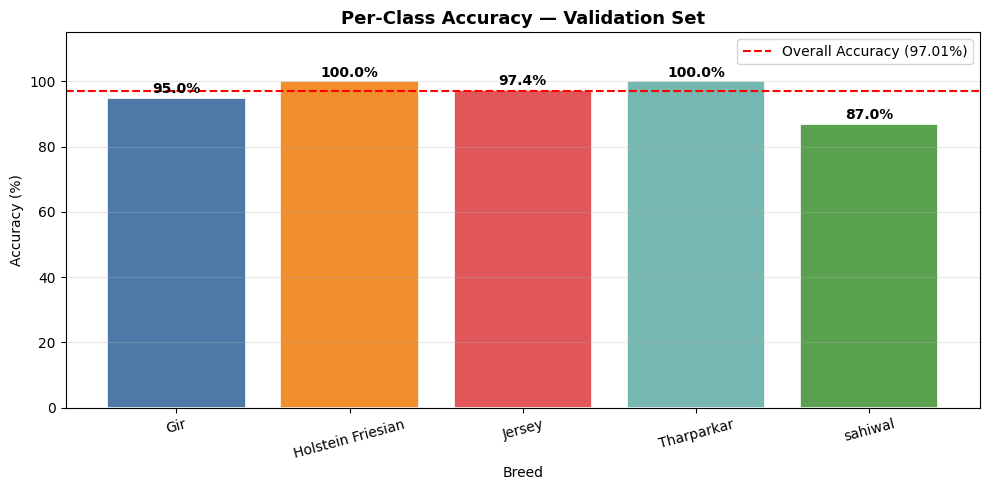

Figure saved: vit_per_class_accuracy.png


In [ ]:
# ═══════════════════════════════════════════════════════════════
# CELL 15 — Per-Class Accuracy Bar Chart
# ═══════════════════════════════════════════════════════════════
per_class_acc = cm_norm.diagonal() * 100

fig, ax = plt.subplots(figsize=(10, 5))
bar_colors = [colors[i] for i in range(NUM_CLASSES)]
bars = ax.bar(class_names, per_class_acc, color=bar_colors,
              edgecolor='white', linewidth=1.2)

for bar, val in zip(bars, per_class_acc):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.5,
            f'{val:.1f}%', ha='center', va='bottom',
            fontweight='bold', fontsize=10)

ax.axhline(y=val_acc*100, color='red', linestyle='--', linewidth=1.5,
           label=f'Overall Accuracy ({val_acc*100:.2f}%)')
ax.set_title('Per-Class Accuracy — Validation Set', fontsize=13, fontweight='bold')
ax.set_xlabel('Breed')
ax.set_ylabel('Accuracy (%)')
ax.set_ylim([0, 115])
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('vit_per_class_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: vit_per_class_accuracy.png')

---
## 🖼️ Section 7 — Sample Predictions (Correct & Incorrect)

In [ ]:
# ═══════════════════════════════════════════════════════════════
# CELL 16 — Sample Prediction Grid (val images with confidence)
# ═══════════════════════════════════════════════════════════════
def denormalize(tensor):
    """Reverse ImageNet normalization for display."""
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std  = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    img  = tensor.cpu() * std + mean
    return img.permute(1, 2, 0).clamp(0, 1).numpy()

def show_sample_predictions(model, dataset, class_names, n_correct=10, n_wrong=10,
                             device=DEVICE, save_path=None):
    """
    Shows n_correct correct predictions and n_wrong incorrect predictions.
    Green border = correct, Red border = wrong.
    """
    model.eval()
    correct_samples, wrong_samples = [], []

    indices = list(range(len(dataset)))
    random.shuffle(indices)

    with torch.no_grad():
        for idx in indices:
            img_tensor, true_label = dataset[idx]
            inp    = img_tensor.unsqueeze(0).to(device)
            output = model(inp)
            probs  = torch.softmax(output, dim=1).squeeze().cpu().numpy()
            pred   = probs.argmax()
            conf   = probs[pred]

            entry = (img_tensor, true_label, pred, conf)
            if pred == true_label and len(correct_samples) < n_correct:
                correct_samples.append(entry)
            elif pred != true_label and len(wrong_samples) < n_wrong:
                wrong_samples.append(entry)

            if len(correct_samples) >= n_correct and len(wrong_samples) >= n_wrong:
                break

    all_samples  = correct_samples + wrong_samples
    n_cols       = 5
    n_rows       = (len(all_samples) + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols,
                              figsize=(n_cols * 3, n_rows * 3.2))
    fig.suptitle('Sample Predictions — ✅ Correct (green) | ❌ Wrong (red)',
                 fontsize=13, fontweight='bold')

    for i, ax in enumerate(axes.flat):
        if i < len(all_samples):
            img_t, true_lbl, pred_lbl, conf = all_samples[i]
            img_disp = denormalize(img_t)
            ax.imshow(img_disp)
            is_correct = (pred_lbl == true_lbl)
            border_col = 'green' if is_correct else 'red'

            title_text = (f'True: {class_names[true_lbl]}\n'
                          f'Pred: {class_names[pred_lbl]} ({conf*100:.1f}%)')
            ax.set_title(title_text, fontsize=8,
                         color='darkgreen' if is_correct else 'darkred')
            for spine in ax.spines.values():
                spine.set_edgecolor(border_col)
                spine.set_linewidth(3)
        else:
            ax.axis('off')
        ax.set_xticks([]); ax.set_yticks([])

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f'Figure saved: {save_path}')
    plt.show()

show_sample_predictions(
    vit_model, val_dataset, class_names,
    n_correct=10, n_wrong=10,
    save_path='vit_sample_predictions.png'
)

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
# ═══════════════════════════════════════════════════════════════
# CELL 17 — Per-Class Correct/Wrong Sample Grid
# ═══════════════════════════════════════════════════════════════
def show_per_class_samples(model, dataset, class_names, n_per_class=4,
                            device=DEVICE, save_path=None):
    """
    Shows n_per_class prediction examples for each class.
    Each row = one class. Green = correct, Red = wrong.
    """
    model.eval()
    per_class = {i: [] for i in range(len(class_names))}

    indices = list(range(len(dataset)))
    random.shuffle(indices)

    with torch.no_grad():
        for idx in indices:
            img_t, true_lbl = dataset[idx]
            if len(per_class[true_lbl]) >= n_per_class:
                continue
            inp    = img_t.unsqueeze(0).to(device)
            output = model(inp)
            probs  = torch.softmax(output, dim=1).squeeze().cpu().numpy()
            pred   = probs.argmax()
            conf   = probs[pred]
            per_class[true_lbl].append((img_t, true_lbl, pred, conf))

            if all(len(v) >= n_per_class for v in per_class.values()):
                break

    fig, axes = plt.subplots(len(class_names), n_per_class,
                              figsize=(n_per_class * 3, len(class_names) * 3))
    fig.suptitle('Per-Class Sample Predictions', fontsize=13, fontweight='bold')

    for row, cls_idx in enumerate(range(len(class_names))):
        samples = per_class[cls_idx]
        for col in range(n_per_class):
            ax = axes[row, col] if len(class_names) > 1 else axes[col]
            if col < len(samples):
                img_t, true_lbl, pred_lbl, conf = samples[col]
                ax.imshow(denormalize(img_t))
                is_correct  = (pred_lbl == true_lbl)
                border_col  = 'green' if is_correct else 'red'
                title_color = 'darkgreen' if is_correct else 'darkred'
                ax.set_title(f'{class_names[pred_lbl]}\n{conf*100:.1f}%',
                             fontsize=8, color=title_color)
                for sp in ax.spines.values():
                    sp.set_edgecolor(border_col); sp.set_linewidth(3)
                if col == 0:
                    ax.set_ylabel(class_names[cls_idx], fontsize=9,
                                  fontweight='bold', rotation=0,
                                  labelpad=60, va='center')
            else:
                ax.axis('off')
            ax.set_xticks([]); ax.set_yticks([])

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f'Figure saved: {save_path}')
    plt.show()

show_per_class_samples(
    vit_model, val_dataset, class_names,
    n_per_class=4,
    save_path='vit_per_class_samples.png'
)

Output hidden; open in https://colab.research.google.com to view.

---
## 🔬 Section 8 — Advanced Evaluation

Top-K Accuracy
Top-1 Accuracy : 97.01%
Top-2 Accuracy : 99.00%
Top-3 Accuracy : 99.50%


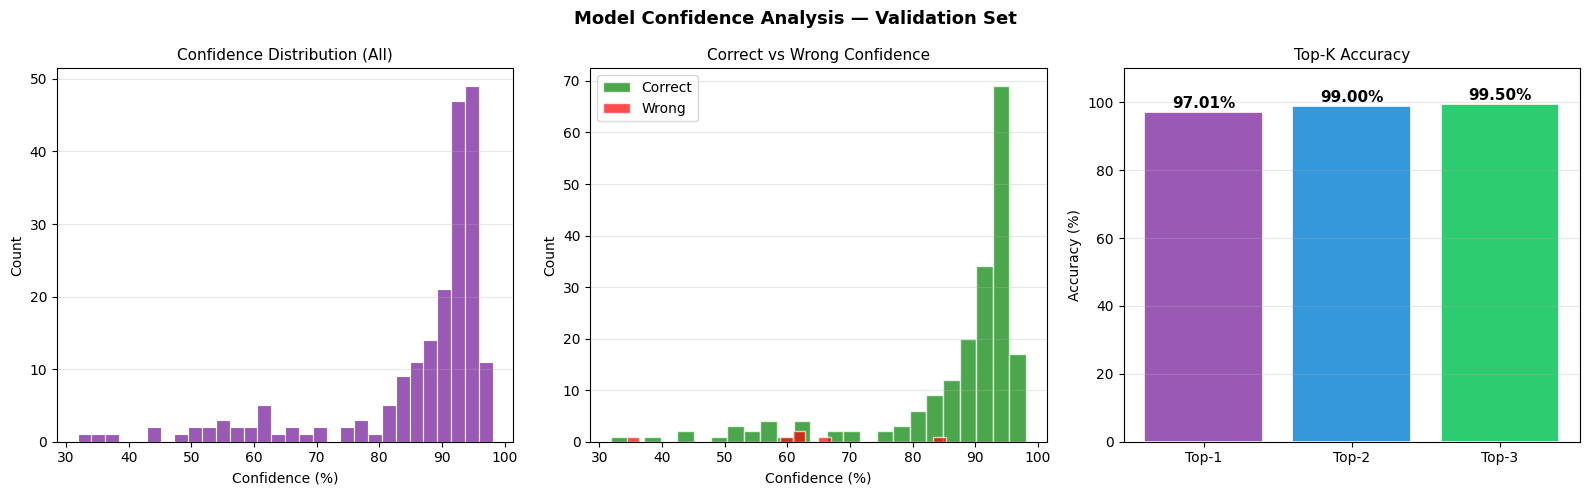

Figure saved: vit_confidence_analysis.png


In [ ]:
# ═══════════════════════════════════════════════════════════════
# CELL 18 — Confidence Distribution & Top-N Accuracy
# ═══════════════════════════════════════════════════════════════
max_probs   = y_probs.max(axis=1)          # confidence of predicted class
is_correct  = (y_pred == y_true)

# ── Top-2 & Top-3 accuracy ──
top2_correct = 0
top3_correct = 0
for i, true_lbl in enumerate(y_true):
    top2 = np.argsort(y_probs[i])[-2:]
    top3 = np.argsort(y_probs[i])[-3:]
    if true_lbl in top2: top2_correct += 1
    if true_lbl in top3: top3_correct += 1

top2_acc = top2_correct / len(y_true)
top3_acc = top3_correct / len(y_true)

print('=' * 45)
print('Top-K Accuracy')
print('=' * 45)
print(f'Top-1 Accuracy : {val_acc*100:.2f}%')
print(f'Top-2 Accuracy : {top2_acc*100:.2f}%')
print(f'Top-3 Accuracy : {top3_acc*100:.2f}%')
print('=' * 45)

# ── Figure: Confidence distributions ──
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Model Confidence Analysis — Validation Set',
             fontsize=13, fontweight='bold')

# All predictions
axes[0].hist(max_probs * 100, bins=30, color='#9b59b6', edgecolor='white',
             linewidth=0.8)
axes[0].set_title('Confidence Distribution (All)', fontsize=11)
axes[0].set_xlabel('Confidence (%)')
axes[0].set_ylabel('Count')
axes[0].grid(axis='y', alpha=0.3)

# Correct vs Wrong
axes[1].hist(max_probs[is_correct] * 100,  bins=25, alpha=0.7,
             label='Correct', color='green', edgecolor='white')
axes[1].hist(max_probs[~is_correct] * 100, bins=25, alpha=0.7,
             label='Wrong',   color='red',   edgecolor='white')
axes[1].set_title('Correct vs Wrong Confidence', fontsize=11)
axes[1].set_xlabel('Confidence (%)')
axes[1].set_ylabel('Count')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

# Top-K bar
topk_accs  = [val_acc * 100, top2_acc * 100, top3_acc * 100]
topk_labels = ['Top-1', 'Top-2', 'Top-3']
topk_colors = ['#9b59b6', '#3498db', '#2ecc71']
bars = axes[2].bar(topk_labels, topk_accs, color=topk_colors,
                   edgecolor='white', linewidth=1.2)
for bar, val in zip(bars, topk_accs):
    axes[2].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.3,
                 f'{val:.2f}%', ha='center', va='bottom',
                 fontweight='bold', fontsize=11)
axes[2].set_title('Top-K Accuracy', fontsize=11)
axes[2].set_ylabel('Accuracy (%)')
axes[2].set_ylim([0, 110])
axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('vit_confidence_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: vit_confidence_analysis.png')

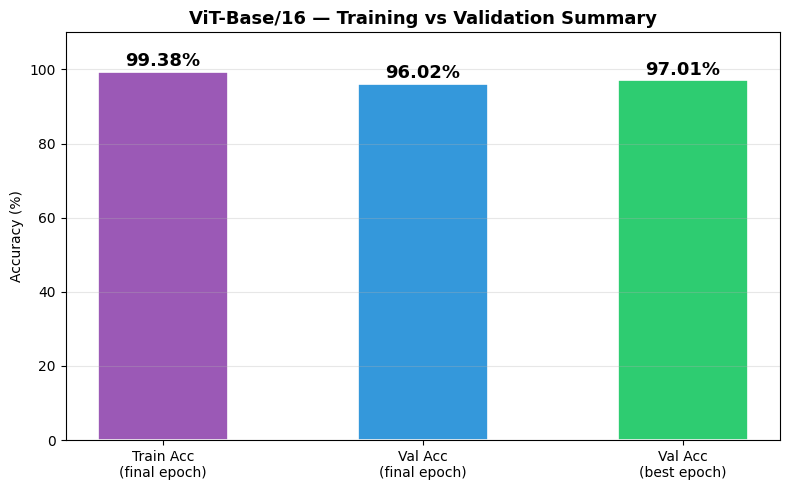

Figure saved: vit_train_val_summary.png


In [ ]:
# ═══════════════════════════════════════════════════════════════
# CELL 19 — Training vs Validation Final Comparison (both phases)
# ═══════════════════════════════════════════════════════════════
final_train_acc = history['train_acc'][-1] * 100
final_val_acc   = history['val_acc'][-1]   * 100
best_val_acc_pct = max(history['val_acc'])  * 100

fig, ax = plt.subplots(figsize=(8, 5))

metrics  = ['Train Acc\n(final epoch)', 'Val Acc\n(final epoch)', 'Val Acc\n(best epoch)']
values   = [final_train_acc, final_val_acc, best_val_acc_pct]
m_colors = ['#9b59b6', '#3498db', '#2ecc71']

bars = ax.bar(metrics, values, color=m_colors, edgecolor='white',
              linewidth=1.2, width=0.5)
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.5,
            f'{val:.2f}%', ha='center', va='bottom',
            fontsize=13, fontweight='bold')

ax.set_title('ViT-Base/16 — Training vs Validation Summary',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Accuracy (%)')
ax.set_ylim([0, 110])
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('vit_train_val_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: vit_train_val_summary.png')

---
## 💾 Section 9 — Save Model & Results

In [ ]:
# ═══════════════════════════════════════════════════════════════
# CELL 20 — Save Model Weights & Metadata
# ═══════════════════════════════════════════════════════════════
# Save final model
torch.save(vit_model.state_dict(), 'ViT_CattleBreed_final.pth')

# Save full checkpoint with metadata
checkpoint = {
    'model_state_dict' : vit_model.state_dict(),
    'class_names'      : class_names,
    'class_to_idx'     : class_to_idx,
    'num_classes'      : NUM_CLASSES,
    'val_accuracy'     : float(val_acc),
    'val_f1_weighted'  : float(val_f1),
    'val_f1_macro'     : float(macro_f1),
    'history'          : history,
    'model_name'       : 'vit_base_patch16_224',
    'img_size'         : IMG_SIZE,
    'imagenet_mean'    : IMAGENET_MEAN,
    'imagenet_std'     : IMAGENET_STD,
}
torch.save(checkpoint, 'ViT_CattleBreed_checkpoint.pth')

# Save results JSON
results = {
    'model'          : 'vit_base_patch16_224',
    'val_accuracy'   : round(val_acc * 100, 4),
    'val_f1_weighted': round(float(val_f1), 4),
    'val_f1_macro'   : round(float(macro_f1), 4),
    'top2_accuracy'  : round(top2_acc * 100, 4),
    'top3_accuracy'  : round(top3_acc * 100, 4),
    'total_epochs'   : len(history['train_acc']),
    'best_val_acc'   : round(best_val_acc_pct, 4),
    'num_classes'    : NUM_CLASSES,
    'class_names'    : class_names,
}

with open('vit_results.json', 'w') as f:
    json.dump(results, f, indent=2)

print('Files saved:')
print('  ViT_CattleBreed_final.pth       — model weights only')
print('  ViT_CattleBreed_checkpoint.pth  — full checkpoint with metadata')
print('  vit_results.json                — evaluation metrics')
print()
print(json.dumps(results, indent=2))

Files saved:
  ViT_CattleBreed_final.pth       — model weights only
  ViT_CattleBreed_checkpoint.pth  — full checkpoint with metadata
  vit_results.json                — evaluation metrics

{
  "model": "vit_base_patch16_224",
  "val_accuracy": 97.0149,
  "val_f1_weighted": 0.9699,
  "val_f1_macro": 0.9616,
  "top2_accuracy": 99.005,
  "top3_accuracy": 99.5025,
  "total_epochs": 44,
  "best_val_acc": 97.0149,
  "num_classes": 5,
  "class_names": [
    "Gir",
    "Holstein Friesian",
    "Jersey",
    "Tharparkar",
    "sahiwal"
  ]
}


---
## 🔮 Section 10 — Inference on a Single Image

In [ ]:
# ═══════════════════════════════════════════════════════════════
# CELL 21 — Single Image Inference Function
# ═══════════════════════════════════════════════════════════════
def predict_single(image_path, model, class_names, device=DEVICE, top_k=3):
    """
    Predicts breed for a single image file.
    Displays the image with top-k confidence scores.

    Args:
        image_path : path to image file
        model      : trained ViT model
        class_names: list of class names
        device     : torch device
        top_k      : number of top predictions to show

    Returns:
        (predicted_class, confidence, all_probs)
    """
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
    ])

    img_pil = Image.open(image_path).convert('RGB')
    inp     = transform(img_pil).unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        output = model(inp)
        probs  = torch.softmax(output, dim=1).squeeze().cpu().numpy()

    top_indices = np.argsort(probs)[::-1][:top_k]
    pred_class  = class_names[top_indices[0]]
    pred_conf   = probs[top_indices[0]]

    # Plot
    fig, axes = plt.subplots(1, 2, figsize=(11, 4),
                              gridspec_kw={'width_ratios': [1, 1.5]})
    axes[0].imshow(img_pil.resize((224, 224)))
    axes[0].set_title(f'Prediction: {pred_class}\nConf: {pred_conf*100:.1f}%',
                      fontsize=12, fontweight='bold')
    axes[0].axis('off')
    for sp in axes[0].spines.values():
        sp.set_edgecolor('#9b59b6'); sp.set_linewidth(3)

    top_names  = [class_names[i] for i in top_indices]
    top_probs  = [probs[i] * 100 for i in top_indices]
    bar_colors = ['#9b59b6' if i == 0 else '#bdc3c7' for i in range(top_k)]
    bars = axes[1].barh(top_names[::-1], top_probs[::-1],
                        color=bar_colors[::-1], edgecolor='white')
    for bar, val in zip(bars, top_probs[::-1]):
        axes[1].text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
                     f'{val:.1f}%', va='center', fontweight='bold', fontsize=10)
    axes[1].set_title(f'Top-{top_k} Predictions', fontsize=12)
    axes[1].set_xlabel('Confidence (%)')
    axes[1].set_xlim([0, 115])
    axes[1].grid(axis='x', alpha=0.3)

    plt.tight_layout()
    plt.show()

    print(f'\n🐄 Predicted Breed : {pred_class}')
    print(f'   Confidence       : {pred_conf*100:.2f}%')
    print(f'   Top-{top_k} predictions:')
    for i in top_indices:
        print(f'     {class_names[i]:<20} {probs[i]*100:.2f}%')

    return pred_class, pred_conf, probs

print('predict_single() function ready.')
print('Usage:')
print('  predict_single("/path/to/image.jpg", vit_model, class_names)')

predict_single() function ready.
Usage:
  predict_single("/path/to/image.jpg", vit_model, class_names)


Demo image      : /content/drive/MyDrive/capstone/cattle dataset/sahiwal/Screenshot 2026-02-04 020954.png
True breed      : sahiwal


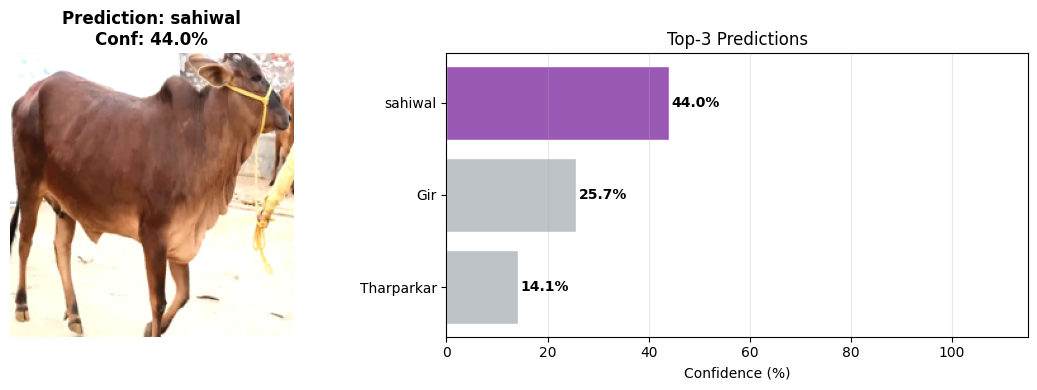


🐄 Predicted Breed : sahiwal
   Confidence       : 43.97%
   Top-3 predictions:
     sahiwal              43.97%
     Gir                  25.69%
     Tharparkar           14.12%

Result: ✅ CORRECT


In [ ]:
# ═══════════════════════════════════════════════════════════════
# CELL 22 — Run Single Image Prediction (Example)
# ═══════════════════════════════════════════════════════════════
# Pick one random image from the validation set for demonstration
rand_idx    = random.randint(0, len(val_dataset) - 1)
sample_path = val_dataset.samples[rand_idx][0]
true_label  = class_names[val_dataset.samples[rand_idx][1]]

print(f'Demo image      : {sample_path}')
print(f'True breed      : {true_label}')

pred_class, conf, _ = predict_single(sample_path, vit_model, class_names, top_k=3)

match = '✅ CORRECT' if pred_class == true_label else '❌ WRONG'
print(f'\nResult: {match}')

---
## 📋 Section 11 — Final Summary

In [ ]:
# ═══════════════════════════════════════════════════════════════
# CELL 23 — Final Summary Dashboard
# ═══════════════════════════════════════════════════════════════
print('\n' + '═' * 60)
print('🐄  ViT-Base/16 — CATTLE BREED CLASSIFIER  🐄')
print('   Final Evaluation Summary')
print('═' * 60)
print(f'  Model             : vit_base_patch16_224 (ImageNet-21k)')
print(f'  Training strategy : 2-phase fine-tuning')
print(f'  Augmentation      : Yes (flip, rotate, jitter, erase)')
print(f'  Total epochs      : {len(history["train_acc"])}')
print()
print(f'  ✅ Val Accuracy   : {val_acc*100:.2f}%')
print(f'  ✅ Best Val Acc   : {best_val_acc_pct:.2f}%')
print(f'  ✅ Weighted F1    : {val_f1:.4f}')
print(f'  ✅ Macro F1       : {macro_f1:.4f}')
print(f'  ✅ Top-2 Accuracy : {top2_acc*100:.2f}%')
print(f'  ✅ Top-3 Accuracy : {top3_acc*100:.2f}%')
print()
print('  Per-Class Recall:')
for i, cls in enumerate(class_names):
    rec = cm_norm[i, i] * 100
    print(f'    {cls:<20} {rec:.2f}%')
print()
print('  Saved files:')
saved_files = [
    'ViT_CattleBreed_final.pth',
    'ViT_CattleBreed_checkpoint.pth',
    'vit_results.json',
    'vit_training_history.png',
    'vit_confusion_matrix_val.png',
    'vit_per_class_accuracy.png',
    'vit_sample_predictions.png',
    'vit_per_class_samples.png',
    'vit_confidence_analysis.png',
    'vit_train_val_summary.png',
    'eda_distribution.png',
    'eda_sample_images.png',
    'eda_augmentation_preview.png',
]
for f in saved_files:
    print(f'    📄 {f}')
print('═' * 60)


════════════════════════════════════════════════════════════
🐄  ViT-Base/16 — CATTLE BREED CLASSIFIER  🐄
   Final Evaluation Summary
════════════════════════════════════════════════════════════
  Model             : vit_base_patch16_224 (ImageNet-21k)
  Training strategy : 2-phase fine-tuning
  Augmentation      : Yes (flip, rotate, jitter, erase)
  Total epochs      : 44

  ✅ Val Accuracy   : 97.01%
  ✅ Best Val Acc   : 97.01%
  ✅ Weighted F1    : 0.9699
  ✅ Macro F1       : 0.9616
  ✅ Top-2 Accuracy : 99.00%
  ✅ Top-3 Accuracy : 99.50%

  Per-Class Recall:
    Gir                  95.00%
    Holstein Friesian    100.00%
    Jersey               97.37%
    Tharparkar           100.00%
    sahiwal              86.96%

  Saved files:
    📄 ViT_CattleBreed_final.pth
    📄 ViT_CattleBreed_checkpoint.pth
    📄 vit_results.json
    📄 vit_training_history.png
    📄 vit_confusion_matrix_val.png
    📄 vit_per_class_accuracy.png
    📄 vit_sample_predictions.png
    📄 vit_per_class_samples.png


In [17]:
import shutil
shutil.copy('/content/ViT_CattleBreed_Complete.ipynb', '/content/cattle-detection-project/')

FileNotFoundError: [Errno 2] No such file or directory: '/content/ViT_CattleBreed_Complete.ipynb'

In [19]:
!ls /content/drive/MyDrive

 12215005
'12215005_Dileep (10).pdf'
'12215005_Dileep (1) (1).pdf'
'12215005_Dileep (11).pdf'
'12215005_Dileep (12).pdf'
'12215005_Dileep (1).pdf'
'12215005_Dileep (2).pdf'
'12215005_Dileep (3).pdf'
'12215005_Dileep (4).pdf'
'12215005_Dileep (5).pdf'
'12215005_Dileep (6).pdf'
'12215005_Dileep (7).pdf'
'12215005_Dileep (8).pdf'
'12215005_Dileep (9).pdf'
 12215005_Dileep.pdf
'30 mcqs based on unit 1.docx'
'Admit Card (1).pdf'
 capstone
'Car sales.zip'
'CertificateOfCompletion_Getting Started with DevOps.pdf'
 Classroom
'Colab Notebooks'
'coursera certificate.pdf'
'cse 121 gantt chart (1).pdf'
'cse 121 gantt chart.pdf'
'cse dream cv (1).pdf'
'cse dream cv.pdf'
'CSE GANTT CHART.pdf'
 cv.jpg
 dileep.pdf
'generate 30 questions from unit 2.docx'
'Generate 40 questions from unit 3.docx'
'INT 233 certificate.pdf'
'INT 234 certificate.pdf'
'IPO Analysis of Innovana Thinklabs Limited.pptx'
'Jacob AI.png'
'karri Dileep sanjay Data camp roll no 64.png'
 karridileepsanjayreddy_64_12215005_K22CD.R
'K